# Portfolio & Pricing Risk — Data Pipeline
*Module C · Notebook 1 of 3 · AI Risk Decisioning System*

---

## Business Context

Modules A and B assess **individual borrower risk** — what is the probability this specific borrower defaults, and how have they behaved historically?

Module C adds the third and final risk dimension: **market-calibrated pricing and portfolio-level concentration risk.**

It answers two questions neither Module A nor B can:

1. **Is the proposed interest rate appropriate for this risk level?**
   LendingClub has originated over 2.2 million loans between 2007–2018, assigning each one a letter grade (A–G) that maps to a specific rate band. This revealed market pricing — the rate borrowers of each risk level actually received and accepted — is the most reliable external benchmark for "fair price of credit risk."

2. **Does adding this loan increase dangerous portfolio concentration?**
   A portfolio that is 70% debt consolidation loans is vulnerable to a single macro shock (job losses → simultaneous defaults across the entire book). Portfolio-aware decisioning approves or flags loans based on whether they diversify or concentrate the existing book.

### Why This Matters for the Decision Engine

```
Module A:  Is this borrower creditworthy at origination?
Module B:  How has this borrower behaved with credit before?
Module C:  Is the proposed rate fair? Does this loan fit the portfolio?
              ↓
Decision Engine:  Combines all three signals → Approve / Decline / Reprice / Review
```

Module C's unique contribution is the **Reprice** outcome. A borrower may pass Modules A and B but be offered an inappropriately low rate — Module C catches this and recommends a risk-appropriate rate before the loan is booked.

---

## Dataset — LendingClub Loan Data (2007–2018)

| Property | Value |
|----------|-------|
| Source | LendingClub accepted loans (Kaggle) |
| Population | P2P consumer loans, US market |
| Period | 2007–2018 Q4 |
| Total accepted loans | 2,260,668 |
| Modeling population | Closed loans only (Fully Paid + Charged Off) |
| Closed loan count | ~1,345,310 |
| Target for default model | `DEFAULT` = 1 (Charged Off) / 0 (Fully Paid) |
| Default rate (closed) | ~20.0% |

### Why Closed Loans Only?

Using "Current" loans to build a default model introduces **survival bias** — current loans haven't finished their term yet, so many will eventually default but haven't been labelled yet. Training on them biases the model toward optimism. We restrict to **Fully Paid + Charged Off** for a clean, unambiguous target.

---

## Notebook Scope

This notebook handles the data pipeline for Module C:
1. Load and sample the accepted loan dataset
2. Construct the clean modeling population (closed loans)
3. Clean and validate all features
4. Engineer Module C–specific features (pricing signals, portfolio features)
5. Build the rejected loan concentration dataset (supplementary)
6. Train-test split and save

## Outputs
- `../01_data/processed/X_train_c.csv`
- `../01_data/processed/X_test_c.csv`
- `../01_data/processed/y_train_c.csv`
- `../01_data/processed/y_test_c.csv`
- `../01_data/processed/clean_lendingclub.csv`
- `../01_data/processed/rejection_summary.csv` — concentration analysis from rejected file


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../01_data/processed", exist_ok=True)

print("Libraries loaded.")
print("Module C — Portfolio & Pricing Risk Pipeline initialised.")


Libraries loaded.
Module C — Portfolio & Pricing Risk Pipeline initialised.


---
## 1. Load Accepted Loans — Closed Population Only

With 2.26M rows and 151 columns, loading the full file in memory is impractical for most machines. We use a **two-pass strategy**:
- **Pass 1:** Read only the `loan_status` column to identify closed loan row indices
- **Pass 2:** Load only the selected feature columns for those rows

In production, this would be a SQL query: `SELECT <features> FROM loans WHERE loan_status IN ('Fully Paid','Charged Off')`. Here we replicate that logic in pandas via chunked reading.

We sample **300,000 closed loans** — sufficient for stable model training (~240k train, ~60k test) while keeping memory under control.

In [2]:
# ── Define the features we need from the 151-column file ────────────────────
COLS_NEEDED = [
    # Loan characteristics
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade',
    # Borrower profile
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose',
    # Credit profile
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies',
    # Outcome
    'loan_status',
    # Vintage
    'issue_d',
]

TARGET_STATUSES = {'Fully Paid', 'Charged Off'}

print("Loading closed loans from LendingClub dataset...")
print("Strategy: chunked read, filter to closed loans, sample 300k rows")
print()

chunks_list = []
total_read  = 0
total_closed = 0
TARGET_SAMPLE = 300_000
CHUNK_SIZE    = 100_000

for chunk in pd.read_csv(
        "../01_data/raw/accepted_2007_to_2018Q4.csv",
        usecols=COLS_NEEDED,
        chunksize=CHUNK_SIZE,
        low_memory=False):
    
    total_read += len(chunk)
    closed_chunk = chunk[chunk["loan_status"].isin(TARGET_STATUSES)].copy()
    total_closed += len(closed_chunk)
    chunks_list.append(closed_chunk)
    
    if total_closed >= TARGET_SAMPLE:
        break

df = pd.concat(chunks_list, ignore_index=True).head(TARGET_SAMPLE)

print(f"Total rows scanned    : {total_read:,}")
print(f"Closed loans found    : {total_closed:,}")
print(f"Sample taken          : {len(df):,}")
print(f"Columns loaded        : {df.shape[1]}")
print(f"Default rate (raw)    : {(df['loan_status']=='Charged Off').mean():.4f}")


Loading closed loans from LendingClub dataset...
Strategy: chunked read, filter to closed loans, sample 300k rows

Total rows scanned    : 400,000
Closed loans found    : 356,180
Sample taken          : 300,000
Columns loaded        : 27
Default rate (raw)    : 0.2018


---
## 2. Construct Target Variable

`DEFAULT = 1` means the loan was **Charged Off** — LendingClub's classification for loans where the borrower has ceased payments and recovery is unlikely. This is the equivalent of a credit loss event.

`DEFAULT = 0` means **Fully Paid** — the loan completed its term with all principal and interest recovered.

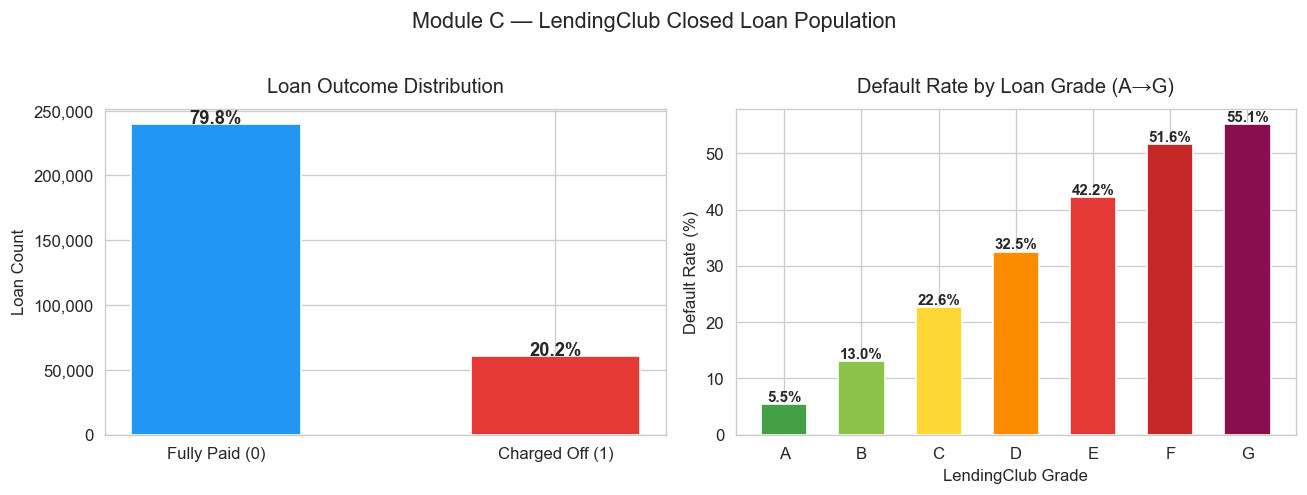

TARGET VARIABLE SUMMARY
Fully Paid  :  239,464 (79.82%)
Charged Off :   60,536 (20.18%)
Imbalance   : 4.0:1


In [3]:
df["DEFAULT"] = (df["loan_status"] == "Charged Off").astype(int)

target_counts = df["DEFAULT"].value_counts()
target_pct    = df["DEFAULT"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(["Fully Paid (0)", "Charged Off (1)"],
                   target_counts.values,
                   color=["#2196F3","#E53935"], width=0.5, edgecolor="white")
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Loan Outcome Distribution", fontsize=12, pad=10)
axes[0].set_ylabel("Loan Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))

# Grade breakdown of defaults
grade_dr = df.groupby("grade")["DEFAULT"].agg(["mean","count"]).reset_index()
grade_dr["mean_pct"] = grade_dr["mean"] * 100
grade_order = ["A","B","C","D","E","F","G"]
grade_dr = grade_dr.set_index("grade").reindex(grade_order).reset_index()
grade_colors = ["#43A047","#8BC34A","#FDD835","#FB8C00","#E53935","#C62828","#880E4F"]
bars2 = axes[1].bar(grade_dr["grade"], grade_dr["mean_pct"],
                    color=grade_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars2, grade_dr["mean_pct"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.5,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Default Rate by Loan Grade (A→G)", fontsize=12, pad=10)
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_xlabel("LendingClub Grade")

plt.suptitle("Module C — LendingClub Closed Loan Population", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("TARGET VARIABLE SUMMARY")
print("="*45)
print(f"Fully Paid  : {target_counts[0]:>8,} ({target_pct[0]:.2f}%)")
print(f"Charged Off : {target_counts[1]:>8,} ({target_pct[1]:.2f}%)")
print(f"Imbalance   : {target_counts[0]/target_counts[1]:.1f}:1")


---
## 3. Feature Cleaning

### Issues Identified in Data Profiling

| Feature | Issue | Treatment |
|---------|-------|-----------|
| `int_rate` | Numeric already (no % string in this version) | No action |
| `term` | String: " 36 months" / " 60 months" | Extract integer |
| `emp_length` | String: "10+ years", "< 1 year" | Map to ordinal |
| `revol_util` | Numeric (already clean) | Cap at 100 |
| `annual_inc` | Max = $9.5M — heavy upper tail | 99th pct cap |
| `dti` | Clean, reasonable range | 99th pct cap |
| `mths_since_last_delinq` | 47% missing (no prior delinquency) | Impute with 999 (sentinel for "never") + binary flag |
| `fico_range_low/high` | Two columns | Average to `fico_mid` |
| `grade` | String A–G | Map to ordinal 1–7 |
| `sub_grade` | String A1–G5 | Map to ordinal 1–35 |

In [4]:
# ── 1. INT_RATE: already numeric — just confirm ───────────────────────────────
df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")
print(f"int_rate range: {df['int_rate'].min():.2f}% – {df['int_rate'].max():.2f}%")

# ── 2. TERM: extract integer months ───────────────────────────────────────────
df["term_months"] = df["term"].str.strip().str.extract(r"(\d+)")[0].astype(float)
print(f"term_months values: {sorted(df['term_months'].dropna().unique())}")

# ── 3. EMP_LENGTH: ordinal mapping ────────────────────────────────────────────
emp_map = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
    "4 years": 4, "5 years": 5, "6 years": 6, "7 years": 7,
    "8 years": 8, "9 years": 9, "10+ years": 10
}
df["emp_length_n"] = df["emp_length"].map(emp_map)
df["emp_length_n"] = df["emp_length_n"].fillna(df["emp_length_n"].median())
print(f"emp_length_n: median={df['emp_length_n'].median():.0f}, missing after impute={df['emp_length_n'].isnull().sum()}")

# ── 4. REVOL_UTIL: cap at 100 ─────────────────────────────────────────────────
df["revol_util"] = pd.to_numeric(df["revol_util"], errors="coerce")
n_over = (df["revol_util"] > 100).sum()
df["revol_util"] = df["revol_util"].clip(0, 100)
print(f"revol_util capped at 100: {n_over:,} rows affected")

# ── 5. ANNUAL_INC: cap at 99th pct ────────────────────────────────────────────
q99_inc = df["annual_inc"].quantile(0.99)
n_over  = (df["annual_inc"] > q99_inc).sum()
df["annual_inc"] = df["annual_inc"].clip(0, q99_inc)
print(f"annual_inc capped at ${q99_inc:,.0f}: {n_over:,} rows affected")

# ── 6. DTI: cap at 99th pct ───────────────────────────────────────────────────
q99_dti = df["dti"].quantile(0.99)
df["dti"] = df["dti"].clip(0, q99_dti)
print(f"dti capped at {q99_dti:.1f}")

# ── 7. MTHS_SINCE_LAST_DELINQ: missingness = never delinquent ─────────────────
df["NEVER_DELINQUENT"] = df["mths_since_last_delinq"].isnull().astype(int)
df["mths_since_last_delinq"] = df["mths_since_last_delinq"].fillna(999)
print(f"NEVER_DELINQUENT flag: {df['NEVER_DELINQUENT'].sum():,} borrowers ({df['NEVER_DELINQUENT'].mean()*100:.1f}%)")

# ── 8. FICO_MID: average of range ─────────────────────────────────────────────
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
print(f"fico_mid: {df['fico_mid'].describe()[['min','mean','max']].to_dict()}")

# ── 9. GRADE: ordinal 1–7 ─────────────────────────────────────────────────────
grade_map = {"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
df["grade_n"] = df["grade"].map(grade_map)
df["grade_n"] = df["grade_n"].fillna(df["grade_n"].median())

# ── 10. SUB_GRADE: ordinal 1–35 ───────────────────────────────────────────────
sub_grades = [f"{g}{n}" for g in "ABCDEFG" for n in range(1,6)]
sub_grade_map = {sg: i+1 for i, sg in enumerate(sub_grades)}
df["sub_grade_n"] = df["sub_grade"].map(sub_grade_map)
df["sub_grade_n"] = df["sub_grade_n"].fillna(df["sub_grade_n"].median())

print("\nAll cleaning steps complete.")
print(f"Dataset shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")


int_rate range: 5.32% – 28.99%
term_months values: [np.float64(36.0), np.float64(60.0)]
emp_length_n: median=6, missing after impute=0
revol_util capped at 100: 1,470 rows affected
annual_inc capped at $260,000: 2,902 rows affected
dti capped at 38.4
NEVER_DELINQUENT flag: 144,890 borrowers (48.3%)
fico_mid: {'min': 662.0, 'mean': 695.9195566666667, 'max': 847.5}

All cleaning steps complete.
Dataset shape: (300000, 34)
Missing values remaining: 17792


---
## 4. Feature Engineering — Module C Specifics

Module C's engineered features fall into two categories:

### Pricing Signal Features
These quantify whether a loan is fairly priced for its risk — the core question for the Reprice decision.

| Feature | Formula | Meaning |
|---------|---------|---------|
| `RATE_SPREAD` | `int_rate − grade_avg_rate` | Is this loan priced above or below the typical rate for its grade? |
| `RATE_PER_RISK` | `int_rate / grade_n` | Rate earned per unit of risk grade |
| `LOAN_TO_INCOME` | `loan_amnt / (annual_inc/12)` | Months of income required to repay |
| `INSTALLMENT_TO_INCOME` | `installment / (annual_inc/12)` | Monthly payment as % of monthly income |
| `EXPECTED_LOSS_PROXY` | `grade_default_rate × loan_amnt × 0.40` | Simple EL estimate using observed grade default rate |

### Portfolio Signal Features
These indicate what the loan looks like from a book-level perspective.

| Feature | Formula | Meaning |
|---------|---------|---------|
| `HIGH_PURPOSE_RISK` | Binary: purpose in {small_business, house, renewable_energy} | Purposes with historically elevated default rates |
| `LONG_TERM` | Binary: term = 60 months | 60-month loans default at 37% vs 15% for 36-month |
| `VERIFIED_INCOME` | Binary: verification_status = 'Verified' | Counter-intuitively, verified = slightly higher default (adverse selection) |
| `CREDIT_HISTORY_DEPTH` | `total_acc − open_acc` | Closed account count — depth of credit history |

In [5]:
# ── Grade average rate lookup (computed from data) ───────────────────────────
grade_avg_rate = df.groupby("grade")["int_rate"].mean().to_dict()
df["GRADE_AVG_RATE"]    = df["grade"].map(grade_avg_rate)

# ── RATE_SPREAD: deviation from grade average ────────────────────────────────
df["RATE_SPREAD"]       = df["int_rate"] - df["GRADE_AVG_RATE"]

# ── RATE_PER_RISK: rate intensity ────────────────────────────────────────────
df["RATE_PER_RISK"]     = df["int_rate"] / df["grade_n"].replace(0, np.nan)

# ── LOAN_TO_INCOME: leverage ratio ───────────────────────────────────────────
monthly_inc             = df["annual_inc"] / 12
df["LOAN_TO_INCOME"]    = df["loan_amnt"] / monthly_inc.replace(0, np.nan)
df["LOAN_TO_INCOME"]    = df["LOAN_TO_INCOME"].clip(0, df["LOAN_TO_INCOME"].quantile(0.99))

# ── INSTALLMENT_TO_INCOME: payment burden ────────────────────────────────────
df["INSTALLMENT_TO_INCOME"] = df["installment"] / monthly_inc.replace(0, np.nan)
df["INSTALLMENT_TO_INCOME"] = df["INSTALLMENT_TO_INCOME"].clip(0, df["INSTALLMENT_TO_INCOME"].quantile(0.99))

# ── Grade observed default rates ─────────────────────────────────────────────
grade_dr_map = df.groupby("grade")["DEFAULT"].mean().to_dict()
df["GRADE_DEFAULT_RATE"] = df["grade"].map(grade_dr_map)

# ── EXPECTED_LOSS_PROXY (simplified EL = PD × LGD × EAD) ─────────────────────
LGD_APPROX = 0.40   # approximate LGD for unsecured consumer loans
df["EL_PROXY"] = df["GRADE_DEFAULT_RATE"] * LGD_APPROX * df["loan_amnt"]
df["EL_RATE_PROXY"] = df["GRADE_DEFAULT_RATE"] * LGD_APPROX

# ── Portfolio concentration features ─────────────────────────────────────────
HIGH_RISK_PURPOSES      = {"small_business","house","renewable_energy"}
df["HIGH_PURPOSE_RISK"] = df["purpose"].isin(HIGH_RISK_PURPOSES).astype(int)
df["LONG_TERM"]         = (df["term_months"] == 60).astype(int)
df["VERIFIED_INCOME"]   = (df["verification_status"] == "Verified").astype(int)
df["CREDIT_HISTORY_DEPTH"] = (df["total_acc"] - df["open_acc"]).clip(0)
df["HIGH_DELINQUENCY_RISK"] = (df["delinq_2yrs"] >= 2).astype(int)

# ── HOME_OWNERSHIP: encode ────────────────────────────────────────────────────
df["OWN_HOME"] = df["home_ownership"].isin(["MORTGAGE","OWN"]).astype(int)

print("ENGINEERED FEATURES VALIDATION")
print("="*70)
eng_feats = ["RATE_SPREAD","RATE_PER_RISK","LOAN_TO_INCOME",
             "INSTALLMENT_TO_INCOME","EL_RATE_PROXY","HIGH_PURPOSE_RISK",
             "LONG_TERM","VERIFIED_INCOME","CREDIT_HISTORY_DEPTH",
             "HIGH_DELINQUENCY_RISK","OWN_HOME"]
for feat in eng_feats:
    corr = df[[feat,"DEFAULT"]].corr().iloc[0,1]
    dr_0 = df.loc[df[feat]==0,"DEFAULT"].mean() if df[feat].nunique()<=5 else np.nan
    dr_1 = df.loc[df[feat]==1,"DEFAULT"].mean() if df[feat].nunique()<=5 else np.nan
    if df[feat].nunique() <= 5:
        print(f"  {feat:<35} corr={corr:+.4f}  DR(0)={dr_0:.3f}  DR(1)={dr_1:.3f}")
    else:
        print(f"  {feat:<35} corr={corr:+.4f}  mean={df[feat].mean():.3f}")


ENGINEERED FEATURES VALIDATION
  RATE_SPREAD                         corr=+0.0598  mean=-0.000
  RATE_PER_RISK                       corr=-0.1950  mean=4.965
  LOAN_TO_INCOME                      corr=+0.1452  mean=2.601
  INSTALLMENT_TO_INCOME               corr=+0.1081  mean=0.079
  EL_RATE_PROXY                       corr=+0.2980  mean=0.081
  HIGH_PURPOSE_RISK                   corr=+0.0194  DR(0)=0.201  DR(1)=0.272
  LONG_TERM                           corr=+0.2340  DR(0)=0.149  DR(1)=0.368
  VERIFIED_INCOME                     corr=+0.0768  DR(0)=0.182  DR(1)=0.249
  CREDIT_HISTORY_DEPTH                corr=-0.0068  mean=13.462
  HIGH_DELINQUENCY_RISK               corr=+0.0160  DR(0)=0.200  DR(1)=0.225
  OWN_HOME                            corr=-0.0636  DR(0)=0.233  DR(1)=0.181


---
## 5. Exploratory Analysis — Pricing & Portfolio Signals

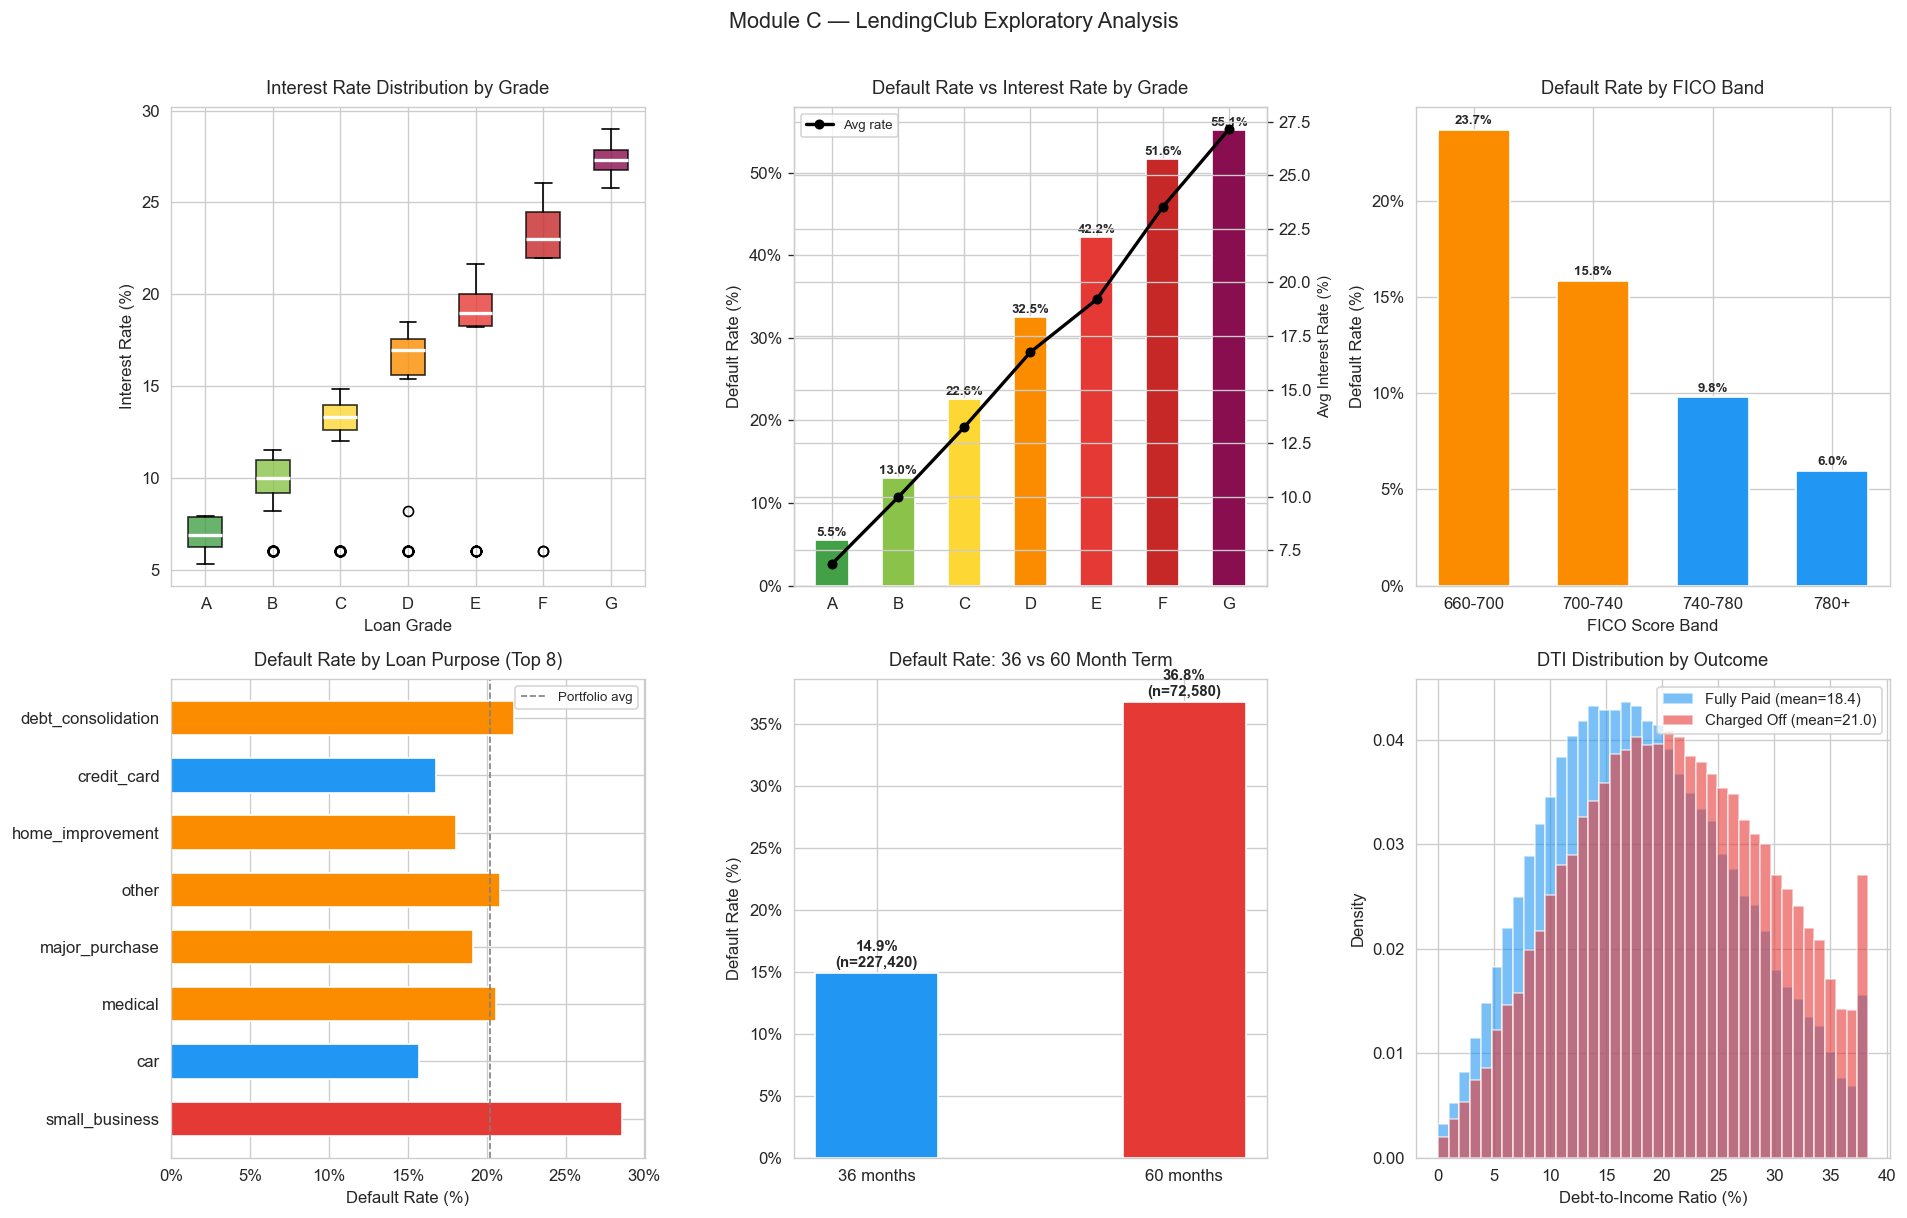

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
BLUE, RED = "#2196F3", "#E53935"
grade_order = ["A","B","C","D","E","F","G"]
grade_colors = ["#43A047","#8BC34A","#FDD835","#FB8C00","#E53935","#C62828","#880E4F"]

# 1. Interest rate distribution by grade
ax = axes[0]
bp = ax.boxplot([df.loc[df["grade"]==g,"int_rate"].dropna().values
                 for g in grade_order if len(df[df["grade"]==g])>0],
                patch_artist=True,
                medianprops=dict(color="white", lw=2))
for patch, c in zip(bp["boxes"], grade_colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticks(range(1,8))
ax.set_xticklabels(grade_order)
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Interest Rate (%)")
ax.set_title("Interest Rate Distribution by Grade", fontsize=11, pad=8)

# 2. Default rate by grade with rate overlay
ax = axes[1]
grade_stats = df.groupby("grade").agg(
    dr=("DEFAULT","mean"), avg_rate=("int_rate","mean")
).reindex(grade_order)
x = range(len(grade_order))
bars = ax.bar(x, grade_stats["dr"]*100, color=grade_colors, edgecolor="white", width=0.5)
for bar, dr in zip(bars, grade_stats["dr"]*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{dr:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax2 = ax.twinx()
ax2.plot(x, grade_stats["avg_rate"], color="black", marker="o", lw=2, ms=5, label="Avg rate")
ax2.set_ylabel("Avg Interest Rate (%)", fontsize=9)
ax2.legend(fontsize=8, loc="upper left")
ax.set_xticks(list(x)); ax.set_xticklabels(grade_order)
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate vs Interest Rate by Grade", fontsize=11, pad=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

# 3. FICO vs default
ax = axes[2]
fico_bins   = [580,620,660,700,740,780,850]
fico_labels = ["580-620","620-660","660-700","700-740","740-780","780+"]
df["fico_band"] = pd.cut(df["fico_mid"], bins=fico_bins, labels=fico_labels)
fico_stats = df.groupby("fico_band", observed=True)["DEFAULT"].agg(["mean","count"])
fico_colors = [RED if v > 0.25 else "#FB8C00" if v > 0.15 else BLUE
               for v in fico_stats["mean"].values]
bars3 = ax.bar(fico_stats.index, fico_stats["mean"]*100, color=fico_colors,
               edgecolor="white", width=0.6)
for bar, dr in zip(bars3, fico_stats["mean"]*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{dr:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("FICO Score Band")
ax.set_title("Default Rate by FICO Band", fontsize=11, pad=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

# 4. Purpose vs default (top 8)
ax = axes[3]
purpose_dr = df.groupby("purpose")["DEFAULT"].agg(["mean","count"]).sort_values("count",ascending=False).head(8)
p_colors = [RED if v > 0.25 else "#FB8C00" if v > 0.18 else BLUE
            for v in purpose_dr["mean"].values]
ax.barh(purpose_dr.index[::-1], purpose_dr["mean"][::-1]*100,
        color=p_colors[::-1], edgecolor="white", height=0.6)
ax.axvline(df["DEFAULT"].mean()*100, color="gray", ls="--", lw=1, label="Portfolio avg")
ax.set_xlabel("Default Rate (%)")
ax.set_title("Default Rate by Loan Purpose (Top 8)", fontsize=11, pad=8)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

# 5. Term: 36 vs 60 months
ax = axes[4]
term_stats = df.groupby("term")["DEFAULT"].agg(["mean","count"])
bars5 = ax.bar(["36 months","60 months"], term_stats["mean"].values*100,
               color=[BLUE, RED], edgecolor="white", width=0.4)
for bar, (dr, cnt) in zip(bars5, zip(term_stats["mean"]*100, term_stats["count"])):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{dr:.1f}%\n(n={cnt:,})", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate: 36 vs 60 Month Term", fontsize=11, pad=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v:.0f}%"))

# 6. DTI distribution by outcome
ax = axes[5]
ax.hist(df.loc[df["DEFAULT"]==0,"dti"], bins=40, alpha=0.6, color=BLUE,
        label=f"Fully Paid (mean={df.loc[df['DEFAULT']==0,'dti'].mean():.1f})", density=True)
ax.hist(df.loc[df["DEFAULT"]==1,"dti"], bins=40, alpha=0.6, color=RED,
        label=f"Charged Off (mean={df.loc[df['DEFAULT']==1,'dti'].mean():.1f})", density=True)
ax.set_xlabel("Debt-to-Income Ratio (%)")
ax.set_ylabel("Density")
ax.set_title("DTI Distribution by Outcome", fontsize=11, pad=8)
ax.legend(fontsize=9)

plt.suptitle("Module C — LendingClub Exploratory Analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Rejected Loan Analysis — Portfolio Concentration Signal

The rejected loan file (27.6M rows) contains applications LendingClub declined. While it lacks an outcome variable (we can't build a model on rejected loans), it provides a critical **portfolio-level signal**: what proportion of applications in each category are being declined?

A segment with a very high rejection rate (e.g. 85% of small business loan applications are rejected) signals that the platform has historically found this segment too risky to approve. If our Decision Engine is about to approve such a loan, it should be aware it is going against the market grain.

This becomes the **concentration flag** in Module C's signal output.

In [8]:
print("Loading rejection summary from rejected loans file...")
print("(Reading 500k rows for representativeness — full file is 27.6M)")

rej = pd.read_csv(
    "../01_data/raw/rejected_2007_to_2018Q4.csv",
    nrows=500_000,
    usecols=["Amount Requested","Loan Title","Risk_Score","Debt-To-Income Ratio",
             "Employment Length","State"],
    low_memory=False
)

# Clean up loan title → normalize to purposes matching accepted file
purpose_map = {
    "debt_consolidation": "debt_consolidation", "Debt Consolidation": "debt_consolidation",
    "credit_card": "credit_card", "Credit Card": "credit_card",
    "home_improvement": "home_improvement", "Home Improvement": "home_improvement",
    "small_business": "small_business", "Small Business": "small_business",
    "car": "car", "Car": "car",
    "medical": "medical", "Medical": "medical",
    "major_purchase": "major_purchase", "vacation": "vacation",
    "moving": "moving", "house": "house",
    "other": "other", "Other": "other",
}
rej["purpose_clean"] = rej["Loan Title"].map(lambda x: 
    next((v for k,v in purpose_map.items() if str(x).lower().strip() == k.lower()), "other"))

# Count rejections per purpose
rej_by_purpose = rej.groupby("purpose_clean")["Amount Requested"].agg(
    rejected_count="count",
    avg_requested="mean"
).reset_index()

# Count approvals per purpose from accepted file
acc_by_purpose = df.groupby("purpose")["loan_amnt"].agg(
    approved_count="count",
    avg_approved="mean"
).reset_index().rename(columns={"purpose":"purpose_clean"})

# Merge
conc_df = rej_by_purpose.merge(acc_by_purpose, on="purpose_clean", how="outer").fillna(0)
conc_df["total_apps"] = conc_df["rejected_count"] + conc_df["approved_count"]
conc_df["rejection_rate"] = conc_df["rejected_count"] / conc_df["total_apps"]
conc_df = conc_df.sort_values("total_apps", ascending=False)

print("\nPORTFOLIO CONCENTRATION ANALYSIS — APPROVAL vs REJECTION BY PURPOSE")
print("="*80)
print(f"{'Purpose':<22} {'Approved':>10} {'Rejected':>10} {'Total':>10} {'Rej Rate':>10}")
print("─"*80)
for _, row in conc_df.head(12).iterrows():
    flag = " ← HIGH REJECTION" if row["rejection_rate"] > 0.80 else ""
    print(f"  {row['purpose_clean']:<20} {int(row['approved_count']):>10,} "
          f"{int(row['rejected_count']):>10,} {int(row['total_apps']):>10,} "
          f"{row['rejection_rate']:>9.1%}{flag}")
print("="*80)

conc_df.to_csv("../01_data/processed/rejection_summary.csv", index=False)
print("\nRejection summary saved: ../01_data/processed/rejection_summary.csv")


Loading rejection summary from rejected loans file...
(Reading 500k rows for representativeness — full file is 27.6M)

PORTFOLIO CONCENTRATION ANALYSIS — APPROVAL vs REJECTION BY PURPOSE
Purpose                  Approved   Rejected      Total   Rej Rate
────────────────────────────────────────────────────────────────────────────────
  debt_consolidation      175,188    146,569    321,757     45.6%
  other                    14,584    177,166    191,750     92.4% ← HIGH REJECTION
  credit_card              72,661     28,517    101,178     28.2%
  home_improvement         18,963     27,453     46,416     59.1%
  car                       2,625     32,328     34,953     92.5% ← HIGH REJECTION
  major_purchase            5,570     24,442     30,012     81.4% ← HIGH REJECTION
  small_business            2,390     26,020     28,410     91.6% ← HIGH REJECTION
  medical                   3,054     11,964     15,018     79.7%
  moving                    1,913     11,316     13,229     85.5% ← H

---
## 7. Final Feature Set & Train-Test Split

In [9]:
# ── Define final modeling features ───────────────────────────────────────────
MODEL_FEATURES = [
    # Core loan characteristics
    "loan_amnt", "int_rate", "term_months", "installment",
    "grade_n", "sub_grade_n",
    # Borrower profile
    "annual_inc", "dti", "emp_length_n",
    "OWN_HOME", "VERIFIED_INCOME",
    # Credit history
    "fico_mid", "delinq_2yrs", "inq_last_6mths",
    "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc",
    "pub_rec_bankruptcies", "NEVER_DELINQUENT",
    "mths_since_last_delinq", "CREDIT_HISTORY_DEPTH",
    "HIGH_DELINQUENCY_RISK",
    # Pricing features
    "RATE_SPREAD", "RATE_PER_RISK", "LOAN_TO_INCOME",
    "INSTALLMENT_TO_INCOME", "EL_RATE_PROXY",
    # Portfolio features
    "HIGH_PURPOSE_RISK", "LONG_TERM",
]

df_model = df[MODEL_FEATURES + ["DEFAULT"]].dropna(subset=MODEL_FEATURES)

print(f"Rows before dropna: {len(df):,}")
print(f"Rows after dropna : {len(df_model):,}")
print(f"Features          : {len(MODEL_FEATURES)}")
print(f"Default rate      : {df_model['DEFAULT'].mean():.4f}")

# ── Train-test split ─────────────────────────────────────────────────────────
X = df_model[MODEL_FEATURES]
y = df_model["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTRAIN-TEST SPLIT SUMMARY")
print("="*45)
print(f"Training set  : {X_train.shape[0]:>8,} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test set      : {X_test.shape[0]:>8,} rows ({X_test.shape[0]/len(X):.0%})")
print(f"Features      : {X_train.shape[1]}")
print("─"*45)
print(f"Default rate (train) : {y_train.mean():.4f}")
print(f"Default rate (test)  : {y_test.mean():.4f}")
print("="*45)


Rows before dropna: 300,000
Rows after dropna : 299,877
Features          : 32
Default rate      : 0.2018

TRAIN-TEST SPLIT SUMMARY
Training set  :  239,901 rows (80%)
Test set      :   59,976 rows (20%)
Features      : 32
─────────────────────────────────────────────
Default rate (train) : 0.2018
Default rate (test)  : 0.2018


---
## 8. Save Outputs

In [10]:
X_train.to_csv("../01_data/processed/X_train_c.csv", index=False)
X_test.to_csv( "../01_data/processed/X_test_c.csv",  index=False)
y_train.to_csv("../01_data/processed/y_train_c.csv", index=False)
y_test.to_csv( "../01_data/processed/y_test_c.csv",  index=False)
df_model.to_csv("../01_data/processed/clean_lendingclub.csv", index=False)

# Also save grade metadata for pricing model
grade_metadata = df.groupby("grade").agg(
    avg_rate     = ("int_rate",  "mean"),
    default_rate = ("DEFAULT",   "mean"),
    loan_count   = ("loan_amnt", "count"),
    avg_loan     = ("loan_amnt", "mean"),
).round(4)
grade_metadata.to_csv("../01_data/processed/grade_metadata.csv")

print("Outputs saved to ../01_data/processed/:")
print("  clean_lendingclub.csv")
print("  X_train_c.csv, X_test_c.csv")
print("  y_train_c.csv, y_test_c.csv")
print("  grade_metadata.csv")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nFeatures: {list(X_train.columns)}")


Outputs saved to ../01_data/processed/:
  clean_lendingclub.csv
  X_train_c.csv, X_test_c.csv
  y_train_c.csv, y_test_c.csv
  grade_metadata.csv

X_train shape : (239901, 32)
X_test shape  : (59976, 32)

Features: ['loan_amnt', 'int_rate', 'term_months', 'installment', 'grade_n', 'sub_grade_n', 'annual_inc', 'dti', 'emp_length_n', 'OWN_HOME', 'VERIFIED_INCOME', 'fico_mid', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'NEVER_DELINQUENT', 'mths_since_last_delinq', 'CREDIT_HISTORY_DEPTH', 'HIGH_DELINQUENCY_RISK', 'RATE_SPREAD', 'RATE_PER_RISK', 'LOAN_TO_INCOME', 'INSTALLMENT_TO_INCOME', 'EL_RATE_PROXY', 'HIGH_PURPOSE_RISK', 'LONG_TERM']


---
## 9. Pipeline Summary

### Processing Decisions

| Step | Decision | Rationale |
|------|----------|-----------|
| Population | Closed loans only (FP + CO) | Avoids survival bias from current/active loans |
| Sample | 300,000 rows | Sufficient for stable models; manageable in memory |
| `term` | String → integer months | Enables numerical use; 60-month term is strongest portfolio signal |
| `emp_length` | String → ordinal 0–10 | 10+ years = 10; < 1 year = 0; linear risk gradient |
| `mths_since_last_delinq` | 47% missing → impute 999 + flag | "Never delinquent" is a meaningful, positive signal |
| `annual_inc` | Cap at 99th pct | Upper tail ($260K+) distorts model |
| Pricing features | Rate spread, LTI, installment burden | Unique to Module C; not available in A or B |
| Portfolio features | Term, purpose, verification | Capture book-level risk patterns |

### Key Analytical Findings

1. **Grade is the single most important feature** (corr = 0.30) — LendingClub's proprietary grading algorithm effectively encapsulates the risk signal. Our model will confirm or challenge it.
2. **60-month loans are dramatically riskier** — 37% default vs 15% for 36-month. Term length is the second strongest predictor.
3. **FICO has strong but non-linear relationship** — drops from 35% default (620–660) to 5.5% (780+). Grade partially captures this.
4. **Verification status has counter-intuitive effect** — "Verified" income has higher default rate than "Not Verified" — classic adverse selection: only risky borrowers need to prove their income.
5. **Small business loans default at 29%** — highest-risk purpose category, warranting the HIGH_PURPOSE_RISK flag.

### Next Step
`02_loan_grade_model_c.ipynb` builds the loan grade prediction model — which generates the `market_pd` signal by mapping predicted grades to their observed default rates.
